In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

final_df = pd.read_csv("../../data/07_portfolios_metadata/complete_metadata.csv", index_col="Unnamed: 0")

## Sector

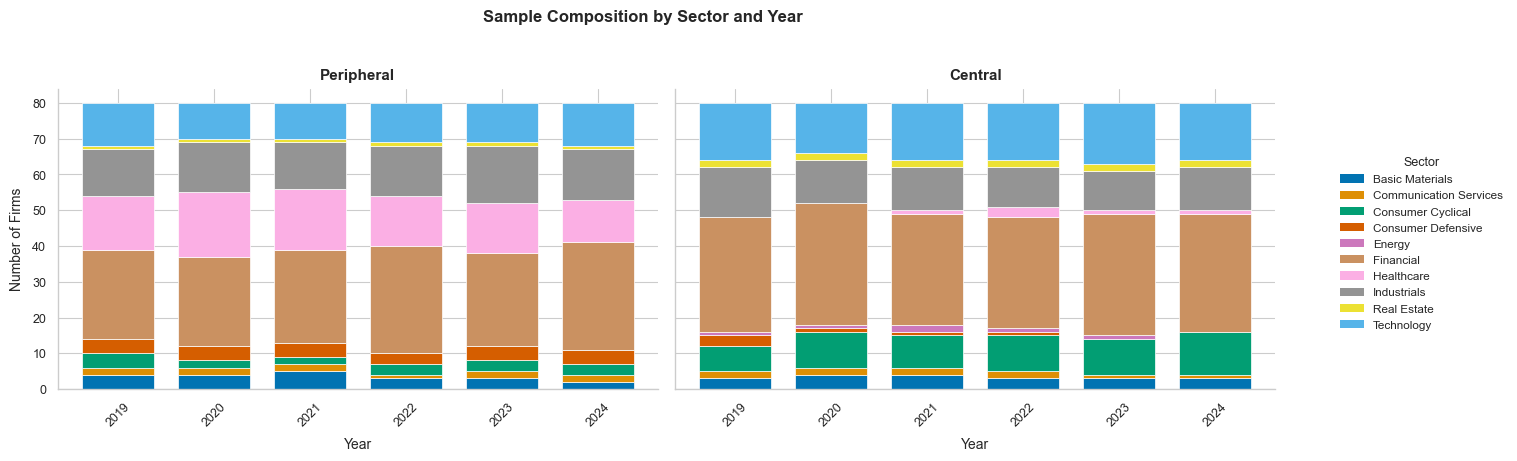

In [185]:
sector_counts = (
    final_df
    .groupby(["portfolio", "year", "Sector"])
    .size()
    .reset_index(name="n_firms")
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Reshape: one wide DataFrame per portfolio ---
def pivot_portfolio(portfolio):
    return (
        sector_counts
        .query("portfolio == @portfolio")
        .pivot_table(index="year", columns="Sector", values="n_firms", fill_value=0)
    )

central    = pivot_portfolio("central")
peripheral = pivot_portfolio("peripheral")

# Ensure both panels share the same sector columns (same order/colors)
all_sectors = sorted(
    sector_counts["Sector"].unique().tolist()
)
central    = central.reindex(columns=all_sectors, fill_value=0)
peripheral = peripheral.reindex(columns=all_sectors, fill_value=0)

# --- Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("colorblind", n_colors=len(all_sectors))
color_map = dict(zip(all_sectors, palette))

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, df_wide, title in zip(
    axes,
    [peripheral, central],
    ["Peripheral", "Central"],
):
    df_wide.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[color_map[s] for s in df_wide.columns],
        edgecolor="white",
        linewidth=0.5,
        width=0.75,
        legend=False,
    )
    ax.set_title(title, fontsize=11, fontweight="bold", pad=7)
    ax.set_xlabel("Year", fontsize=10, labelpad=6)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[0].set_ylabel("Number of Firms", fontsize=10, labelpad=6)
axes[1].set_ylabel("")

# --- Single shared legend to the right ---
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color_map[s], linewidth=0)
    for s in all_sectors
]
fig.legend(
    handles, all_sectors,
    title="Sector",
    title_fontsize=9,
    fontsize=8.5,
    loc="center right",
    bbox_to_anchor=(1.17, 0.5),
    frameon=False,
    ncol=1,
)

sns.despine(fig=fig)
plt.suptitle("Sample Composition by Sector and Year", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("sector_composition_panels.pdf", dpi=300, bbox_inches="tight")
plt.show()

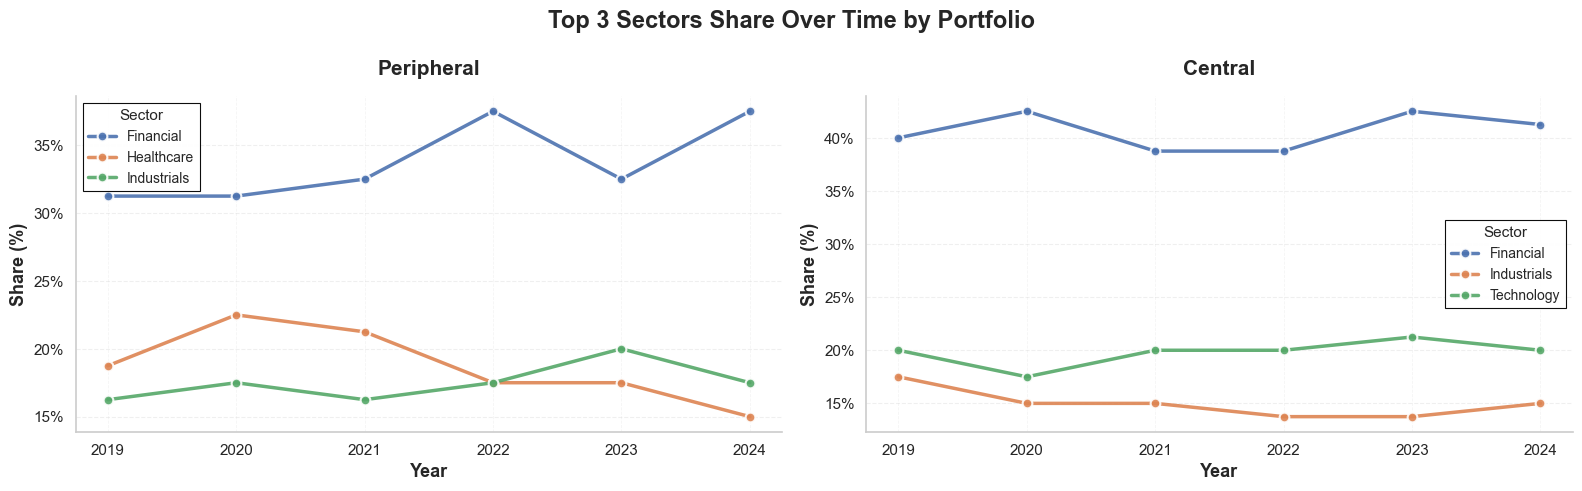

In [186]:
# Calculate sector counts and shares
sector_counts = (
    final_df
    .groupby(["portfolio", "year", "Sector"])
    .size()
    .reset_index(name="n_firms")
)

top_sectors = (
    sector_counts
    .groupby(["portfolio", "Sector"])["n_firms"]
    .sum()
    .reset_index()
    .sort_values(["portfolio", "n_firms"], ascending=[True, False])
    .groupby("portfolio")
    .head(3)
)

portfolio_totals = (
    sector_counts
    .groupby(["portfolio", "year"])["n_firms"]
    .sum()
    .reset_index(name="total_firms")
)

sector_counts_top3 = sector_counts.merge(
    top_sectors[["portfolio", "Sector"]],
    on=["portfolio", "Sector"],
    how="inner"
)

sector_counts_top3 = (
    sector_counts_top3
    .merge(portfolio_totals, on=["portfolio", "year"], how="left")
)

sector_counts_top3["share"] = (
    sector_counts_top3["n_firms"] / sector_counts_top3["total_firms"]
)

sector_counts_top3["share_pct"] = 100 * sector_counts_top3["share"]

# Set publication-quality style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.3)

portfolios = ["peripheral", "central"]  # Changed order to peripheral first

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True, sharey=False)
axes = axes.flatten()

for ax, portfolio in zip(axes, portfolios):
    data_p = sector_counts_top3[
        sector_counts_top3["portfolio"] == portfolio
    ].copy()
    
    # Get unique sectors for this portfolio
    sectors_in_portfolio = data_p["Sector"].unique()
    
    # Plot each sector separately for better control
    for i, sector in enumerate(sectors_in_portfolio):
        sector_data = data_p[data_p["Sector"] == sector]
        ax.plot(
            sector_data["year"],
            sector_data["share_pct"],
            marker='o',
            linewidth=2.5,
            markersize=7,
            label=sector,
            markeredgecolor='white',
            markeredgewidth=1.5,
            alpha=0.9
        )
    
    # Styling
    ax.set_title(
        portfolio.capitalize(), 
        fontsize=15, 
        fontweight="bold",
        pad=15
    )
    ax.set_xlabel("Year", fontsize=13, fontweight="bold")
    ax.set_ylabel("Share (%)", fontsize=13, fontweight="bold")
    
    # Legend
    ax.legend(
        title="Sector",
        fontsize=10,
        title_fontsize=11,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        framealpha=0.95,
        loc='best'
    )
    
    # Clean up axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # Grid
    ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.grid(axis="x", linestyle="--", alpha=0.2, linewidth=0.6)
    ax.set_axisbelow(True)
    
    # Tick parameters
    ax.tick_params(axis='both', which='major', labelsize=11, width=1.2)
    
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# Add overall title
fig.suptitle(
    'Top 3 Sectors Share Over Time by Portfolio',
    fontsize=17,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

## Boxplots

In [187]:
def plot_metric_boxplot_evolution(
    df,
    metric_prefix,
    portfolios=None,
    log_scale=False,
    figsize=(16, 5),
    showfliers=False,
    ylabel=None,
    title=None,
    save=False,
    out_dir="../../figures",
    dpi=300
):
    """
    Create publication-ready boxplots showing temporal evolution of a metric (metric_YYYY)
    in a grid, one panel per portfolio.
    
    Parameters:
    -----------
    df : DataFrame
        Input data with Ticker, portfolio, and metric_YYYY columns
    metric_prefix : str
        Prefix of metric columns (e.g., 'Market_Cap', 'ROE')
    portfolios : list, optional
        List of portfolios to plot. If None, uses ['peripheral', 'central']
    log_scale : bool
        Whether to use log scale for y-axis
    figsize : tuple
        Figure size (width, height)
    showfliers : bool
        Whether to show outliers
    ylabel : str, optional
        Y-axis label (if None, uses metric_prefix)
    title : str, optional
        Overall figure title
    save : bool
        Whether to save the figure
    out_dir : str
        Output directory for saving
    dpi : int
        Resolution for saving
    """
    
    # Set publication-quality style
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)
    
    # Default portfolios (peripheral first)
    if portfolios is None:
        portfolios = ['peripheral', 'central']
    
    # Identify metric columns (metric_YYYY, exclude _cut)
    metric_cols = df.columns[
        df.columns.str.match(fr"^{metric_prefix}_\d{{4}}$")
    ].tolist()

    if len(metric_cols) == 0:
        raise ValueError(f"No columns found for '{metric_prefix}_YYYY'")

    # Reshape to long format
    metric_long = df.melt(
        id_vars=["Ticker", "portfolio"],
        value_vars=metric_cols,
        var_name="metric_year",
        value_name="value"
    )

    # Extract year
    metric_long["year"] = (
        metric_long["metric_year"]
        .str.replace(f"{metric_prefix}_", "", regex=False)
        .astype(int)
    )

    metric_long = metric_long.dropna(subset=["value"])
    
    # Professional color palette
    box_color = '#2E5C6E'
    median_color = "#22125F"
    
    # Font sizes
    TITLE_SIZE = 15
    LABEL_SIZE = 13
    TICK_SIZE = 11
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, portfolio in zip(axes, portfolios):
        data_p = metric_long[metric_long["portfolio"] == portfolio]
        
        # Get unique years and prepare data
        years = sorted(data_p["year"].unique())
        boxplot_data = [data_p[data_p["year"] == year]["value"].values for year in years]
        
        # Create boxplot
        bp = ax.boxplot(
            boxplot_data,
            labels=years,
            patch_artist=True,
            showfliers=showfliers,
            widths=0.6,
            medianprops=dict(color=median_color, linewidth=2.5),
            boxprops=dict(facecolor=box_color, edgecolor='black', linewidth=1.2, alpha=0.7),
            whiskerprops=dict(color='black', linewidth=1.2),
            capprops=dict(color='black', linewidth=1.2),
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
        )

        # Set log scale if requested
        if log_scale:
            ax.set_yscale("log")
            y_label = f"{ylabel if ylabel else metric_prefix} (log scale)"
        else:
            y_label = ylabel if ylabel else metric_prefix

        # Styling
        ax.set_title(portfolio.capitalize(), fontsize=TITLE_SIZE, fontweight="bold", pad=15)
        ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
        ax.set_ylabel(y_label, fontsize=LABEL_SIZE, fontweight="bold")
        
        # Clean up axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        
        # Grid
        ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
        ax.set_axisbelow(True)
        
        # Tick parameters
        ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE, width=1.2)
        ax.tick_params(axis='x', rotation=45)

    # Add overall title if provided
    if title:
        fig.suptitle(title, fontsize=17, fontweight="bold", y=0.98)

    plt.tight_layout()
    
    # Save figure
    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        
        # Save PNG
        filename = f"{metric_prefix}_evolution.png"
        fig.savefig(
            out_path / filename,
            dpi=dpi,
            bbox_inches="tight",
            facecolor='white',
            edgecolor='none'
        )

    plt.show()

In [188]:
def plot_metric_boxplot_evolution(
    df,
    metric_prefix,
    portfolios=None,
    log_scale=False,
    figsize=(10, 5),
    showfliers=False,
    ylabel=None,
    title=None,
    save=False,
    out_dir="../../figures",
    dpi=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import seaborn as sns
    from pathlib import Path

    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)

    if portfolios is None:
        portfolios = ['peripheral', 'central']

    # --- Identify & reshape ---
    metric_cols = df.columns[
        df.columns.str.match(fr"^{metric_prefix}_\d{{4}}$")
    ].tolist()

    if len(metric_cols) == 0:
        raise ValueError(f"No columns found for '{metric_prefix}_YYYY'")

    metric_long = df.melt(
        id_vars=["Ticker", "portfolio"],
        value_vars=metric_cols,
        var_name="metric_year",
        value_name="value"
    )
    metric_long["year"] = (
        metric_long["metric_year"]
        .str.replace(f"{metric_prefix}_", "", regex=False)
        .astype(int)
    )
    metric_long = metric_long.dropna(subset=["value"])

    years = sorted(metric_long["year"].unique())
    n_years     = len(years)
    n_portfolios = len(portfolios)

    # --- Colors (colorblind-safe) ---
    palette = sns.color_palette("colorblind", n_colors=n_portfolios)
    median_colors = ["#1a1a2e", "#2e1a1a"]          # dark contrast per portfolio

    # --- Layout ---
    # Each year occupies a group; portfolios sit side-by-side within the group
    group_width  = 1.0                               # total width per year group
    box_width    = 0.30
    gap          = 0.05                              # gap between boxes in a group
    offsets      = np.linspace(
        -(n_portfolios - 1) * (box_width + gap) / 2,
         (n_portfolios - 1) * (box_width + gap) / 2,
        n_portfolios
    )

    TITLE_SIZE = 15
    LABEL_SIZE = 13
    TICK_SIZE  = 11

    fig, ax = plt.subplots(figsize=figsize)

    for p_idx, (portfolio, color, med_col) in enumerate(
        zip(portfolios, palette, median_colors)
    ):
        data_p = metric_long[metric_long["portfolio"] == portfolio]

        for y_idx, year in enumerate(years):
            values = data_p[data_p["year"] == year]["value"].dropna().values
            if len(values) == 0:
                continue

            x_pos = y_idx * group_width + offsets[p_idx]

            bp = ax.boxplot(
                values,
                positions=[x_pos],
                widths=box_width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops=dict(color=med_col,  linewidth=2.5),
                boxprops=dict(facecolor=color,   edgecolor="black",
                              linewidth=1.2,     alpha=0.75),
                whiskerprops=dict(color="black", linewidth=1.2),
                capprops=dict(color="black",     linewidth=1.2),
                flierprops=dict(marker="o", markerfacecolor="gray",
                                markersize=4,    alpha=0.5),
            )

    # --- X-axis: one tick per year group ---
    ax.set_xticks([i * group_width for i in range(n_years)])
    ax.set_xticklabels(years, fontsize=TICK_SIZE, rotation=45)

    # --- Log scale ---
    if log_scale:
        ax.set_yscale("log")
        y_label = f"{ylabel if ylabel else metric_prefix} (log scale)"
    else:
        y_label = ylabel if ylabel else metric_prefix

    # --- Labels & spines ---
    ax.set_xlabel("Year",   fontsize=LABEL_SIZE, fontweight="bold", labelpad=8)
    ax.set_ylabel(y_label,  fontsize=LABEL_SIZE, fontweight="bold", labelpad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE, width=1.2)

    # --- Single legend ---
    legend_patches = [
        mpatches.Patch(facecolor=color, edgecolor="black",
                       alpha=0.75, label=p.capitalize())
        for p, color in zip(portfolios, palette)
    ]
    ax.legend(
        handles=legend_patches,
        title="Portfolio",
        title_fontsize=10,
        fontsize=9,
        frameon=False,
    )

    if title:
        fig.suptitle(title, fontsize=17, fontweight="bold", y=1.01)

    plt.tight_layout()

    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            out_path / f"{metric_prefix}_evolution.png",
            dpi=dpi, bbox_inches="tight",
            facecolor="white", edgecolor="none"
        )

    plt.show()

### Market Cap

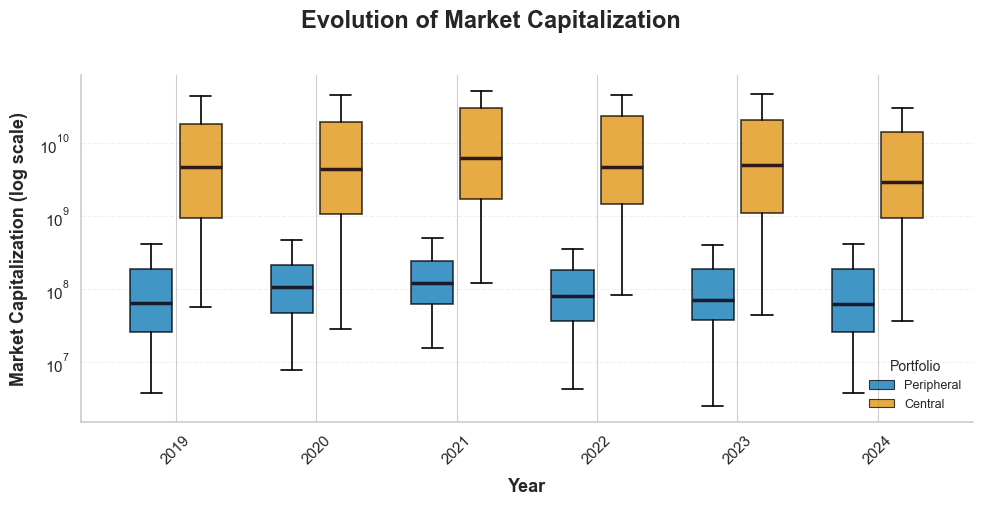

In [189]:
plot_metric_boxplot_evolution(
    df=final_df,
    metric_prefix="mcap",
    portfolios=portfolios,
    log_scale=True,
    ylabel="Market Capitalization",
    title="Evolution of Market Capitalization"
)

### Beta

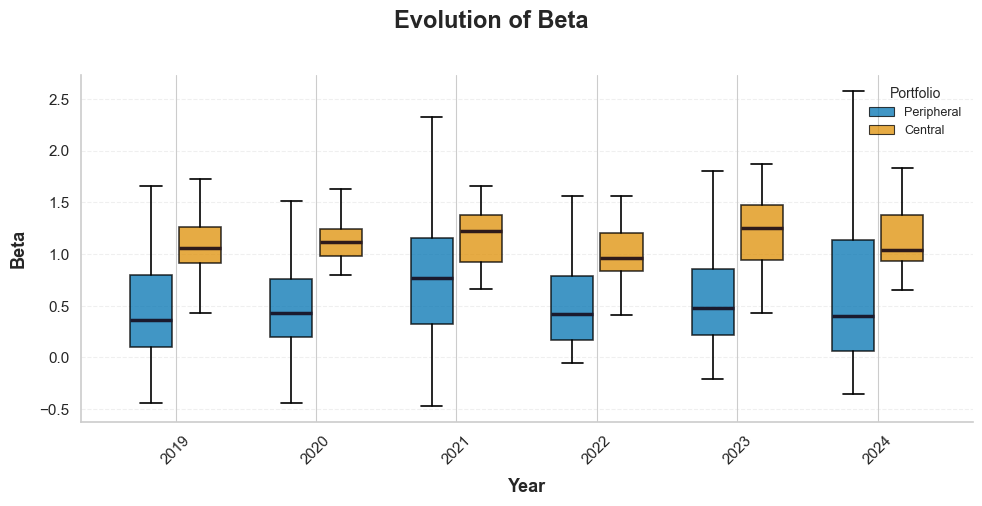

In [190]:
plot_metric_boxplot_evolution(
    df=final_df,
    metric_prefix="beta",
    portfolios=portfolios,
    log_scale=False,
    ylabel="Beta",
    title="Evolution of Beta"
)

### Momentum

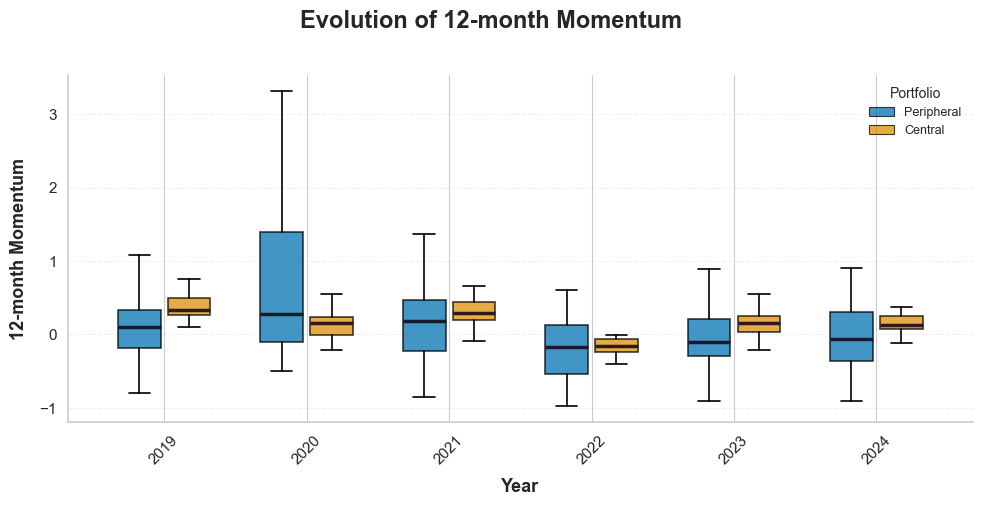

In [191]:
plot_metric_boxplot_evolution(
    df=final_df,
    metric_prefix="momentum12mo",
    portfolios=portfolios,
    log_scale=False,
    ylabel="12-month Momentum",
    title="Evolution of 12-month Momentum"
)

## Composition

In [192]:
assets_by_py = (
    final_df
    .groupby(["portfolio", "year", "n"])["Ticker"]
    .apply(set)
    .reset_index(name="assets")
)

assets_by_py = assets_by_py.sort_values(["portfolio", "n", "year"])

rows = []

# Group by BOTH portfolio and n
for (portfolio, n), g in assets_by_py.groupby(["portfolio", "n"]):
    g = g.sort_values("year").reset_index(drop=True)

    for i in range(1, len(g)):
        year = g.loc[i, "year"]
        prev_assets = g.loc[i - 1, "assets"]
        curr_assets = g.loc[i, "assets"]

        entered = curr_assets - prev_assets
        exited = prev_assets - curr_assets

        rows.append({
            "portfolio": portfolio,
            "year": year,
            "n": n,
            "n_entered": len(entered),
            "n_exited": len(exited),
            "turnover_max": max(len(entered), len(exited)),
            "turnover_avg": (len(entered) + len(exited)) / 2
        })

turnover_df = pd.DataFrame(rows)

sizes = (
    final_df
    .groupby(["portfolio", "n", "year"])["Ticker"]
    .nunique()
    .reset_index(name="n_assets")
    .sort_values(["portfolio", "n", "year"])
)

sizes["n_assets_lag"] = (
    sizes
    .groupby(["portfolio", "n"])["n_assets"]
    .shift(1)
)

turnover_df = turnover_df.merge(
    sizes[["portfolio", "year", "n", "n_assets_lag"]],
    on=["portfolio", "year", "n"],
    how="left"
)

turnover_df["n_stayed"] = (
    turnover_df["n_assets_lag"] - turnover_df["n_exited"]
)

turnover_df["turnover_rate"] = (
    turnover_df["n_exited"] / turnover_df["n_assets_lag"]
)

turnover_df = turnover_df.query("year!=2019")

In [193]:
for i, (portfolio, group) in enumerate(turnover_df.groupby("portfolio")):
    print(portfolio)

central
peripheral


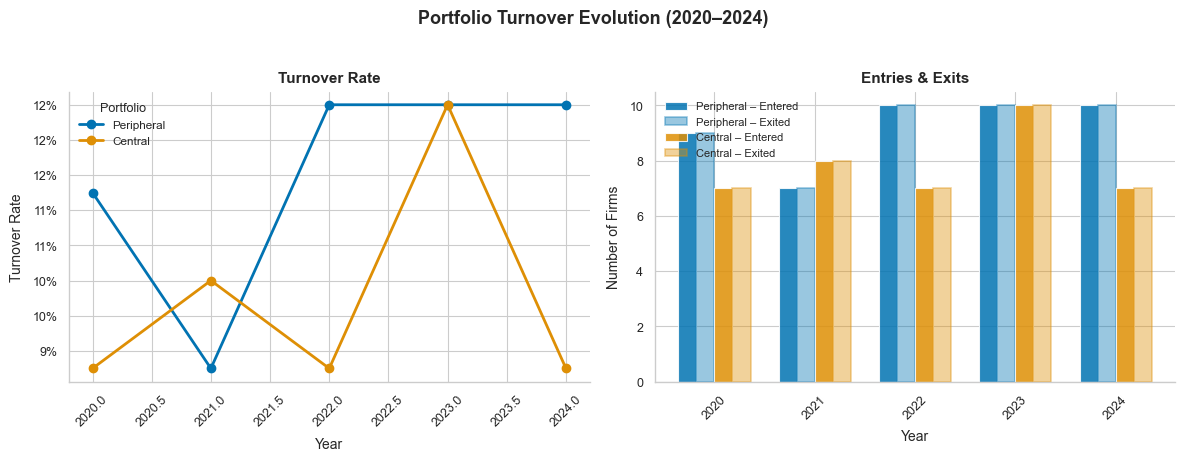

In [194]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("colorblind")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

# -------- Left: Turnover Rate (line) --------
ax = axes[0]
for i, portfolio in enumerate(["peripheral", "central"]):
    group = turnover_df[turnover_df["portfolio"] == portfolio]
    ax.plot(
        group["year"], group["turnover_rate"],
        marker="o", markersize=6,
        lw=2, color=palette[i],
        label=portfolio.capitalize()
    )

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1, decimals=0))
ax.set_title("Turnover Rate", fontsize=11, fontweight="bold", pad=7)
ax.set_xlabel("Year", fontsize=10, labelpad=6)
ax.set_ylabel("Turnover Rate", fontsize=10, labelpad=6)
ax.tick_params(axis="both", labelsize=9)
ax.tick_params(axis="x", rotation=45)

# -------- Right: n_entered / n_exited (grouped bar) --------
ax = axes[1]
width = 0.18
years = turnover_df["year"].unique()
x = range(len(years))

for i, portfolio in enumerate(["peripheral", "central"]):
    group = turnover_df[turnover_df["portfolio"] == portfolio]
    group = group.sort_values("year")
    base = -width if i == 0 else width          # two portfolios → two groups

    ax.bar(
        [xi + base - width / 2 for xi in x], group["n_entered"],
        width=width, color=palette[i], alpha=0.85,
        label=f"{portfolio.capitalize()} – Entered"
    )
    ax.bar(
        [xi + base + width / 2 for xi in x], group["n_exited"],
        width=width, color=palette[i], alpha=0.40,
        edgecolor=palette[i], linewidth=1.2,
        label=f"{portfolio.capitalize()} – Exited"
    )

ax.set_xticks(x)
ax.set_xticklabels(sorted(years), rotation=45, fontsize=9)
ax.set_title("Entries & Exits", fontsize=11, fontweight="bold", pad=7)
ax.set_xlabel("Year", fontsize=10, labelpad=6)
ax.set_ylabel("Number of Firms", fontsize=10, labelpad=6)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.tick_params(axis="both", labelsize=9)

# -------- Shared legend --------
# Left panel: portfolio lines
h1, l1 = axes[0].get_legend_handles_labels()
axes[0].legend(h1[:2], l1[:2],          # only the two portfolio lines
    title="Portfolio", title_fontsize=9,
    fontsize=8.5, frameon=False
)

# Right panel: solid=entered, faded=exited
import matplotlib.patches as mpatches
legend_patches = []
for i, portfolio in enumerate(["peripheral", "central"]):   # ← hardcoded order
    legend_patches += [
        mpatches.Patch(facecolor=palette[i], alpha=0.85,
                       label=f"{portfolio.capitalize()} – Entered"),
        mpatches.Patch(facecolor=palette[i], alpha=0.40,
                       edgecolor=palette[i], linewidth=1.2,
                       label=f"{portfolio.capitalize()} – Exited"),
    ]
axes[1].legend(handles=legend_patches, fontsize=8, frameon=False,
               title_fontsize=9)

# -------- Polish --------
sns.despine(fig=fig)
fig.suptitle("Portfolio Turnover Evolution (2020–2024)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [195]:
portfolios = ["central", "peripheral"]
years = sorted(final_df["year"].unique())

rows = []
for portfolio in portfolios:
    # Always-in (all years)
    df_merged = final_df.query(f"year=={years[0]} and portfolio=='{portfolio}'")[["Ticker"]]
    for year in years[1:]:
        df_merged = df_merged.merge(
            final_df.query(f"year=={year} and portfolio=='{portfolio}'")[["Ticker"]]
        )
    always_in = df_merged.shape[0]

    # In first and last year
    first_and_last = final_df.query(f"year=={years[0]} and portfolio=='{portfolio}'")[["Ticker"]].merge(
        final_df.query(f"year=={years[-1]} and portfolio=='{portfolio}'")[["Ticker"]]
    ).shape[0]

    # Ever appeared
    ever = final_df.query(f"portfolio=='{portfolio}'")["Ticker"].nunique()

    rows.append({
        "Portfolio":                          portfolio.capitalize(),
        f"In all years ({years[0]}–{years[-1]})": always_in,
        f"In {years[0]} & {years[-1]}":           first_and_last,
        "Ever appeared (any year)":           ever,
        "Transient (ever − always-in)":       ever - always_in,
    })

summary_table = pd.DataFrame(rows).set_index("Portfolio")
print(summary_table.to_string())
print("\nLaTeX:\n", summary_table.to_latex())

            In all years (2019–2024)  In 2019 & 2024  Ever appeared (any year)  Transient (ever − always-in)
Portfolio                                                                                                   
Central                           56              63                       106                            50
Peripheral                        55              61                       109                            54

LaTeX:
 \begin{tabular}{lrrrr}
\toprule
 & In all years (2019–2024) & In 2019 & 2024 & Ever appeared (any year) & Transient (ever − always-in) \\
Portfolio &  &  &  &  \\
\midrule
Central & 56 & 63 & 106 & 50 \\
Peripheral & 55 & 61 & 109 & 54 \\
\bottomrule
\end{tabular}



In [196]:
set(final_df.query(f"portfolio=='central'")["Ticker"].unique()).intersection(
    set(final_df.query(f"portfolio=='peripheral'")["Ticker"].unique())
)

set()